In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch

from metashapes.shape import Rectangle, Shape, Ellipse, RegularPolygon
from metashapes import Canvas, UnitCell

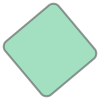

In [11]:
# Define rectangle
center = torch.nn.Parameter(torch.tensor([0.0, 0.0]))
size = torch.nn.Parameter(torch.tensor([50.0, 50.0]))
angle = torch.nn.Parameter(torch.tensor([40.0]))
corner_radius = torch.nn.Parameter(torch.tensor(5.0))

rect = Rectangle(center=center, size=size, angle=angle, corner_radius=corner_radius)
rect.to_shapely()

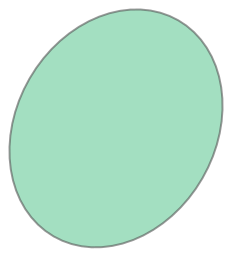

In [10]:
# Define Ellipse
center = torch.nn.Parameter(torch.tensor([0.0, 0.0]))
axes = torch.nn.Parameter(torch.tensor([200.0, 250.0]))
angle = torch.nn.Parameter(torch.tensor(-30.0))

ellipse = Ellipse(center=center, axes=axes, angle=angle)
ellipse.to_shapely()

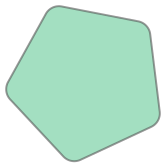

In [14]:
# Define Polygon
center = torch.nn.Parameter(torch.tensor([0.0, 100.0]))
n = 5
side_length = torch.nn.Parameter(torch.tensor(100.0))
angle = torch.nn.Parameter(torch.tensor(25.0))
corner_radius = torch.nn.Parameter(torch.tensor(15.0))

polygon = RegularPolygon(center=center, n=n, side_length=side_length, angle=angle, corner_radius=corner_radius)
polygon.to_shapely()

0.17761477652610283
Gradients:
Center grad: tensor([  8919.5576, -44376.7383])
Side grad: tensor(-64886.8359)
Angle grad: tensor(4814.4849)
Corner radius grad: tensor(7283.0903)


(-5.0, 5.0)

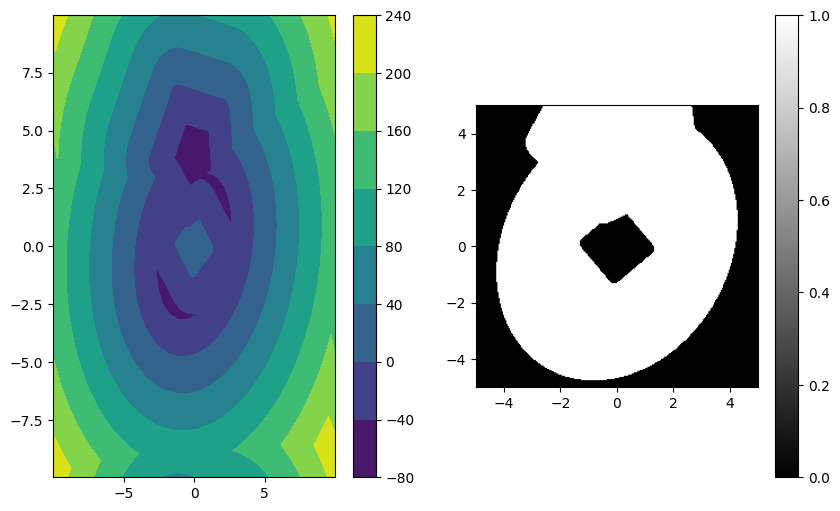

In [15]:
# Define unit cell
canv = Canvas(Lx=500, Ly=500, H=500, W=500)
x, y = canv.grid()

x = x + 0
y = y + 0

shape = ellipse.difference(rect).union(polygon)

unit_cell = UnitCell(shape, canvas=canv, inverted=False)
sdf = unit_cell.sdf(x, y)
im = unit_cell.mask_numpy(soft=False, softness=0.02)
shply = unit_cell.to_shapely()
print(shply.area/unit_cell.unit_cell_shape.to_shapely().area)

# Check grads
sdf.sum().backward()
print("Gradients:")
print("Center grad:", polygon.center.grad)
print("Side grad:", polygon.side_length.grad)
print("Angle grad:", polygon.angle.grad)
print("Corner radius grad:", polygon.corner_radius.grad)

# Plotting
plt.figure(figsize=(10, 6))
plt.subplot(121)
plt.contourf(sdf.detach().numpy(), origin="lower", extent=(-10, 10, -10, 10))
# plt.xlim([-2, 2])
# plt.ylim([-2, 2])

plt.colorbar()

plt.subplot(122)
plt.imshow(im, origin="lower", extent=(-10, 10, -10, 10), cmap='gray')
plt.colorbar()
plt.xlim([-5, 5])
plt.ylim([-5, 5])

Mean Squared Error between unit cell mask and shapely mask: 0.000232


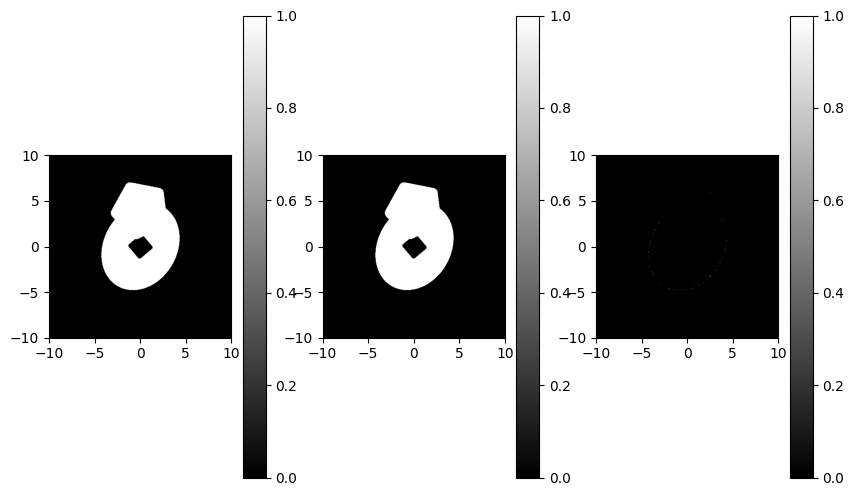

In [19]:
from metashapes.adapters.shapely import shapely_to_numpy
unit_cell_shply = unit_cell.to_shapely()
unit_cell_mask = unit_cell.mask_numpy(soft=False, softness=0.02)
unit_cell_shply_mask = shapely_to_numpy(unit_cell_shply, canvas=canv)

plt.figure(figsize=(10, 6))
plt.subplot(131)
plt.imshow(unit_cell_mask, origin="lower", extent=(-10, 10, -10, 10), cmap='gray')
plt.colorbar()
plt.subplot(132)
plt.imshow(unit_cell_shply_mask, origin="lower", extent=(-10, 10, -10, 10), cmap='gray')
plt.colorbar()
plt.subplot(133)
plt.imshow(unit_cell_mask - unit_cell_shply_mask, origin="lower", extent=(-10, 10, -10, 10), cmap='gray')
plt.colorbar()  

mse = np.mean((unit_cell_mask - unit_cell_shply_mask) ** 2)
print(f"Mean Squared Error between unit cell mask and shapely mask: {mse:.6f}")

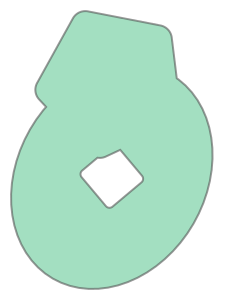

In [17]:
unit_cell_shply

Parametric representation: {'type': 'Scale', 'shape': {'type': 'Translate', 'shape': {'type': 'Rectangle', 'center': [0.0, 0.0], 'size': [3.0, 2.0], 'angle': 20.0, 'corner_radius': 0.5}, 'dx': 1.5, 'dy': 0.5}, 's': 0.5, 'origin': (0.0, 0.0)}
Reconstructed rectangle: tensor(0., grad_fn=<SumBackward0>)
Gradients:
Center grad: tensor([386599.0312, 127096.8750])
Size grad: tensor([-1828000.5000, -1932661.6250])
Angle grad: tensor(6887.5239)
Corner radius grad: tensor(1533540.5000)


(-2.0, 2.0)

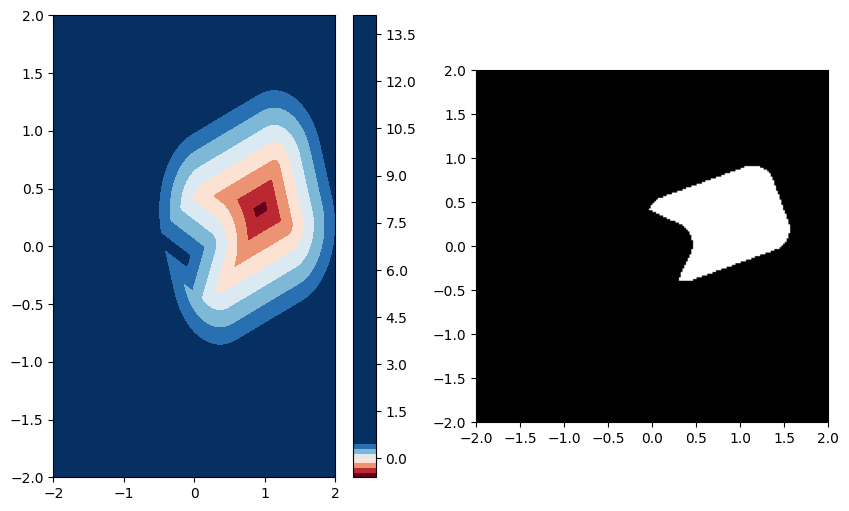

In [15]:
# Grid for sdf
canv = Canvas(20, 20, 1000, 1000)
x, y = canv.grid()

rect2 = rect.translate(1.5, 0.5).scale(0.5)

param = rect2.to_parametric()
print("Parametric representation:", param)

rect2_new = Shape.from_parametric(param)
print("Reconstructed rectangle:", (rect2_new.sdf(x,y) - rect2.sdf(x,y)).abs().sum())

# Move rotate and scale new rect
rect2_new = rect2_new.translate(-1.0, -0.5).scale(1.0).rotate(-45.0)

# New shape
shape = rect2.difference(rect2_new, smooth=False, k=0.4)
sdf = shape.sdf(x, y)
im = shape.mask_numpy(canv, soft=False, softness=0.02)

# Check grads
sdf.sum().backward()
print("Gradients:")
print("Center grad:", rect.center.grad)
print("Size grad:", rect.size.grad)
print("Angle grad:", rect.angle.grad)
print("Corner radius grad:", rect.corner_radius.grad)

# Plotting
plt.figure(figsize=(10, 6))
plt.subplot(121)
plt.contourf(sdf.detach().numpy(), origin="lower", extent=(-10, 10, -10, 10), cmap='RdBu', levels=100)
plt.xlim([-2, 2])
plt.ylim([-2, 2])
plt.clim([-0.5, 0.5])
plt.colorbar()

plt.subplot(122)
plt.imshow(im, origin="lower", extent=(-10, 10, -10, 10), cmap='gray')
plt.xlim([-2, 2])
plt.ylim([-2, 2])

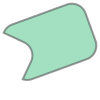

In [11]:
shape.to_shapely()

In [7]:
# Create Canvas
Lx = 200
Ly = 200
H = 400
W = 400

canv = Canvas(Lx, Ly, H, W, spacing=0.2)

device = 'cpu'
dtype=torch.float32

Grad to c_rect: tensor([ 9.5367e-07, -4.0000e+01])
Grad to s_rect: tensor([200.4999, 380.4999])
Grad to a_rect: -4.993427182853338e-07
Grad to r_rect: tensor([-27.9995])
Grad to c_moon: tensor([ 1.9080, -2.8190])
Grad to r_moon: tensor([-96.2197])
Grad to cut_moon: tensor([3467.1514])
Grad to a_moon: -0.19037553668022156
Grad to c_tri: tensor([-0.2942,  0.1166])
Grad to s_tri: tensor([-104.3428])
Grad to a_tri: -0.11472631245851517
Grad to r_tri: tensor([33.4540])
Grad to c_cross: tensor([ 0.0000, 39.9720])
Grad to s_cross: tensor([59.9580])
Grad to w_cross: tensor([151.9021])
Grad to a_cross: 8.322378342029424e-09
Grad to c_ring: tensor([-1.0729e-06, -1.7881e-06])
Grad to or_ring: tensor([61.2348, 93.5113])
Grad to ir_ring: tensor([-47.1854, -31.7385])
Grad to a_ring: -4.369248784996671e-08


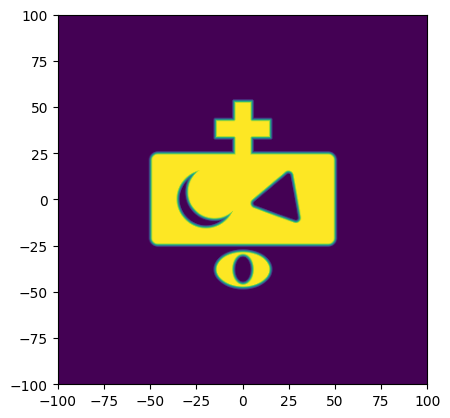

In [11]:
c_rect = torch.nn.Parameter(torch.tensor([0.0, 0.0], device=device, dtype=dtype))
s_rect = torch.nn.Parameter(torch.tensor([100, 50], device=device, dtype=dtype))
a_rect = torch.nn.Parameter(torch.tensor(0.0, device=device, dtype=dtype))
r_rect= torch.nn.Parameter(torch.tensor([4.0], device=device, dtype=dtype))

rect = RoundedRectangle(center=c_rect, size=s_rect, angle=a_rect, radius=r_rect)

c_moon = torch.nn.Parameter(torch.tensor([-20.0, 0.0], device=device, dtype=dtype))
r_moon = torch.nn.Parameter(torch.tensor([15.0], device=device, dtype=dtype))
cut_moon = torch.nn.Parameter(torch.tensor([0.8], device=device, dtype=dtype))
a_moon = torch.nn.Parameter(torch.tensor(40.0, device=device, dtype=dtype))

moon_shp = Moon(center=c_moon, radius=r_moon, cut_ratio=cut_moon, angle=a_moon)

c_tri = torch.nn.Parameter(torch.tensor([20.0, 0.0], device=device, dtype=dtype))
n_tri = 3
s_tri = torch.nn.Parameter(torch.tensor([30.0], device=device, dtype=dtype))
a_tri = torch.nn.Parameter(torch.tensor(-20.0, device=device, dtype=dtype))
r_tri = torch.nn.Parameter(torch.tensor([2.0], device=device, dtype=dtype))

tri = RoundedRegularPolygon(center=c_tri, n=n_tri, side_length=s_tri, angle=a_tri, radius=r_tri)

c_cross = torch.nn.Parameter(torch.tensor([0.0, 38.0], device=device, dtype=dtype))
s_cross = torch.nn.Parameter(torch.tensor([30], device=device, dtype=dtype))
w_cross = torch.nn.Parameter(torch.tensor([10], device=device, dtype=dtype))
a_cross = torch.nn.Parameter(torch.tensor(0.0, device=device, dtype=dtype))

cross = Cross(center=c_cross, size=s_cross, width=w_cross, angle=a_cross)

c_ring = torch.nn.Parameter(torch.tensor([0.0, -38.0], device=device, dtype=dtype))
or_ring = torch.nn.Parameter(torch.tensor([30, 20], device=device, dtype=dtype))
ir_ring = torch.nn.Parameter(torch.tensor([10, 15], device=device, dtype=dtype))
a_ring = torch.nn.Parameter(torch.tensor(0.0, device=device, dtype=dtype))

ring = Ring(center=c_ring, outer_axes=or_ring/2, inner_axes=ir_ring/2, angle=a_ring)


shp = rect.difference(moon_shp).difference(tri).union(cross).union(ring)

shp_image = shp.to_torch(canvas=canv, soft=True, soft_mode="sigmoid", softness=1)
loss = shp_image.sum()
loss.backward()

print(f"Grad to c_rect: {c_rect.grad}")
print(f"Grad to s_rect: {s_rect.grad}")
print(f"Grad to a_rect: {a_rect.grad}")
print(f"Grad to r_rect: {r_rect.grad}")

print(f"Grad to c_moon: {c_moon.grad}")
print(f"Grad to r_moon: {r_moon.grad}")
print(f"Grad to cut_moon: {cut_moon.grad}")
print(f"Grad to a_moon: {a_moon.grad}")

print(f"Grad to c_tri: {c_tri.grad}")
print(f"Grad to s_tri: {s_tri.grad}")
print(f"Grad to a_tri: {a_tri.grad}")
print(f"Grad to r_tri: {r_tri.grad}")

print(f"Grad to c_cross: {c_cross.grad}")
print(f"Grad to s_cross: {s_cross.grad}")
print(f"Grad to w_cross: {w_cross.grad}")
print(f"Grad to a_cross: {a_cross.grad}")

print(f"Grad to c_ring: {c_ring.grad}")
print(f"Grad to or_ring: {or_ring.grad}")
print(f"Grad to ir_ring: {ir_ring.grad}")
print(f"Grad to a_ring: {a_ring.grad}")

geom = shp.to_shapely()

# put here the REAL coordinate range used to build shp_image
xmin, xmax = -100, 100
ymin, ymax = -100, 100

fig, ax = plt.subplots()

ax.imshow(
    shp_image.detach().cpu(),   # important: often needed
    origin="upper",
    extent=[xmin, xmax, ymin, ymax],
)

def plot_shapely(ax, geom, **kwargs):
    if geom.geom_type == "Polygon":
        xs, ys = geom.exterior.xy
        ax.plot(xs, ys, **kwargs)
        for interior in geom.interiors:
            xi, yi = interior.xy
            ax.plot(xi, yi, **kwargs)

    elif geom.geom_type == "MultiPolygon":
        for g in geom.geoms:
            plot_shapely(ax, g, **kwargs)

    elif geom.geom_type in ("LineString", "LinearRing"):
        xs, ys = geom.xy
        ax.plot(xs, ys, **kwargs)

    elif geom.geom_type == "GeometryCollection":
        for g in geom.geoms:
            plot_shapely(ax, g, **kwargs)

#plot_shapely(ax, geom, linewidth=2)

ax.set_aspect("equal")
plt.show()

In [7]:
from metashapes.shape import Rectangle, RoundedRectangle, RoundedCross, Ellipse, RoundedRegularPolygon, RoundedMoon, Shape, Difference, Rotate, Translate
from metashapes.adapters import shape_to_shapely, shape_to_numpy
from metashapes import Canvas
from metashapes.patterned_layer import PatternedLayer

rect = RoundedRectangle(center=(20.0, 0.0), size=(120.0, 80.0), radius=40.0, angle=0.0)
hole = Ellipse(center=(0.0, 0.0), axes=(40.0, 30.0), angle=45.0)
ngn = RoundedRegularPolygon(center=(0.0, 0.0), n=5, side_length=30.0, angle=0.0, radius=4.0)
moon_shape = RoundedMoon(center=(0.0, 90.0), radius=40.0, cut_ratio=0.5, angle=90.0, rounding_radius=5.0)
cross_shape = RoundedCross(center=(70.0, 50.0), size=30.0, width=8.0, radius=2, angle=30.0)

shape_comb = (rect.rotate(15) - hole).rotate(0).translate(0, 0).union(ngn).union(moon_shape).translate(30, -20).rotate(45).difference(cross_shape)

print(shape_comb.to_parametric())

shape = Shape.from_parametric(shape_comb.to_parametric())

{'type': 'Difference', 'left': {'type': 'Rotate', 'shape': {'type': 'Translate', 'shape': {'type': 'Union', 'left': {'type': 'Union', 'left': {'type': 'Translate', 'shape': {'type': 'Rotate', 'shape': {'type': 'Difference', 'left': {'type': 'Rotate', 'shape': {'type': 'RoundedRectangle', 'center': [20.0, 0.0], 'size': [120.0, 80.0], 'radius': 40.0, 'angle': 0.0}, 'angle': 15, 'origin': (0.0, 0.0)}, 'right': {'type': 'Ellipse', 'center': [0.0, 0.0], 'axes': [40.0, 30.0], 'angle': 45.0, 'resolution': 64}}, 'angle': 0, 'origin': (0.0, 0.0)}, 'dx': 0, 'dy': 0}, 'right': {'type': 'RoundedRegularPolygon', 'center': [0.0, 0.0], 'n': 5, 'side_length': 30.0, 'radius': 4.0, 'angle': 0.0}}, 'right': {'type': 'RoundedMoon', 'center': [0.0, 90.0], 'radius': 40.0, 'cut_ratio': 0.5, 'rounding_radius': 5.0, 'angle': 90.0, 'resolution': 64}}, 'dx': 30, 'dy': -20}, 'angle': 45, 'origin': (0.0, 0.0)}, 'right': {'type': 'RoundedCross', 'center': [70.0, 50.0], 'size': 30.0, 'width': 8.0, 'radius': 2, 'angl

In [8]:
# Create Canvas
Lx = 200
Ly = 200
H = 400
W = 400

canv = Canvas(Lx, Ly, H, W, spacing=0.2)

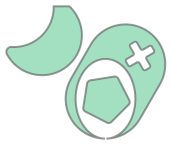

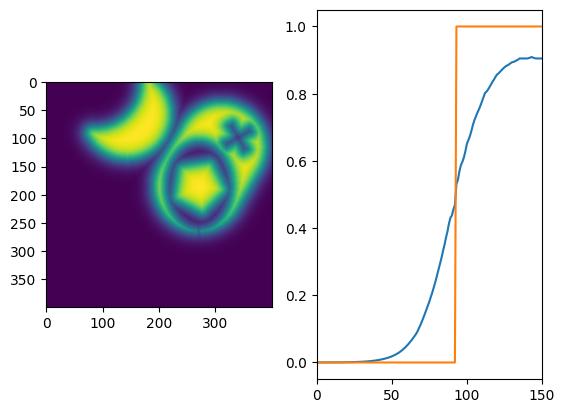

In [9]:
soft_bool = True
mode = "sigmoid"
softness = 4

pl = PatternedLayer(shape_comb, canvas=canv, thickness=5, inverted=False)

plt.subplot(121)
plt.imshow(pl.filled_region.to_numpy(canv, dtype=np.float16, soft=soft_bool, soft_mode=mode, softness=softness))
plt.subplot(122)
plt.plot(pl.filled_region.to_numpy(canv, dtype=np.float16, soft=soft_bool, soft_mode=mode, softness=softness)[120,:])
plt.plot(pl.filled_region.to_numpy(canv, dtype=np.float16)[120,:])
plt.xlim([0, 150])
pl.filled_region.to_shapely()

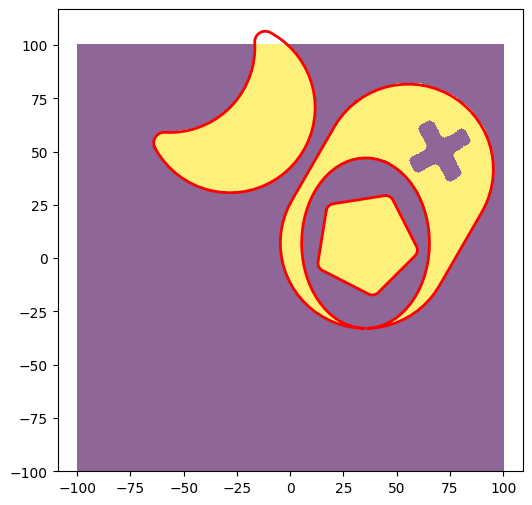

In [10]:
mask = shape_to_numpy(shape, canv)
geom = shape_to_shapely(shape)

plt.figure(figsize=(6, 6))

plt.imshow(
    mask,
    extent=(canv.x0, canv.x1, canv.y0, canv.y1),
    origin="upper",
    interpolation="nearest",
    alpha=0.6,
)

# plot shapely outline
if geom.geom_type == "Polygon":
    x, y = geom.exterior.xy
    plt.plot(x, y, "r-", lw=2)

elif geom.geom_type == "MultiPolygon":
    for poly in geom.geoms:
        x, y = poly.exterior.xy
        plt.plot(x, y, "r-", lw=2)

plt.axis("equal")
plt.show()

In [11]:
# Test rounded rectangle primitive
xc, yc = 0.0, 0.0
w, h = 2.0, 1.0
alpha=30
radius=0.2

rrect = rounded_rectangle(center=(xc, yc), size=(w, h), angle=alpha, radius=radius)
print(rrect.area)
rrect.geom

NameError: name 'rounded_rectangle' is not defined

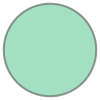

In [ ]:
# Test ellipse primitive
xc, yc = 0.0, 0.0
w, h = 2.0, 2.0
alpha=0

ellipse_shape = ellipse(center=(xc, yc), axes=(w/2, h/2), angle=alpha)
ellipse_shape.geom

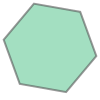

In [ ]:
# Test ngon primitive
xc, yc = 0.0, 0.0
n = 6
side_length = 0.5
alpha = 20

poly = regular_polygon(center=(xc, yc), n = n, side_length=side_length, angle=alpha)
poly.geom

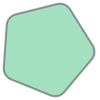

In [ ]:
# Test rounded ngon primitive
xc, yc = 0.0, 0.0
n = 5
side_length = 1.0
alpha = 50
radius = 0.2
rounded_poly = rounded_regular_polygon(center=(xc, yc), n = n, side_length=side_length, angle=alpha, radius=radius)
rounded_poly.geom

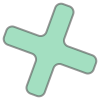

In [ ]:
# Test cross primitive
xc, yc = 0.0, 0.0
size = 2.0
width = 0.4
alpha = -20
radius = 0.13
cross_shape = rounded_cross(center=(xc, yc), size=size, width=width, radius=radius, angle=alpha)
cross_shape.geom

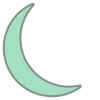

In [ ]:
# Test moon primitive
xc, yc = 0.0, 0.0
radius = 0.5
cut_ratio = 0.8
angle = 30
rounding_radius = 0.01

moon_shape = rounded_moon(center=(xc, yc), radius=radius, cut_ratio=cut_ratio, rounding_radius=rounding_radius, angle=angle)
moon_shape.geom

In [ ]:
# Create Canvas
Lx = 3
Ly = 3
H = 300
W = 300

canv = Canvas(Lx, Ly, H, W, spacing=0.2)

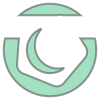

In [ ]:
# Combine shapes
shape1 = (ellipse_shape - rounded_poly - rect).union(moon_shape)

pl = PatternedLayer(shape=shape1, canvas=canv, thickness=0.5, inverted=False)
pl.filled_region.geom

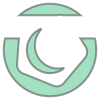

In [ ]:
pl2 = PatternedLayer.from_parametric(pl.to_parametric())
pl2.filled_region.geom

In [ ]:
pl.to_parametric()

{'shape': 'MULTIPOLYGON (((0.9569403357322088 -0.2902846772544623, 0.9238795325112867 -0.3826834323650898, 0.881921264348355 -0.4713967368259976, 0.8314696123025452 -0.5555702330196022, 0.773010453362737 -0.6343932841636455, 0.7071067811865476 -0.7071067811865475, 0.6343932841636455 -0.773010453362737, 0.5555702330196023 -0.8314696123025452, 0.4713967368259978 -0.8819212643483549, 0.3826834323650898 -0.9238795325112867, 0.2902846772544623 -0.9569403357322088, 0.1950903220161283 -0.9807852804032304, 0.0980171403295608 -0.9951847266721968, 0 -1, -0.0980171403295606 -0.9951847266721969, -0.1950903220161282 -0.9807852804032304, -0.2902846772544622 -0.9569403357322089, -0.3826834323650897 -0.9238795325112867, -0.4713967368259977 -0.881921264348355, -0.555570233019602 -0.8314696123025453, -0.6343932841636454 -0.7730104533627371, -0.7071067811865475 -0.7071067811865476, -0.773010453362737 -0.6343932841636455, -0.8314696123025453 -0.5555702330196022, -0.8819212643483549 -0.4713967368259979, -0